# KM-Vector Phase 0 — 데이터 탐색 & 행렬 시각화

이 노트북은 Phase 0의 탐색 작업을 담당합니다.

1. 데이터 로드 확인
2. F 행렬 (처방-본초) 히트맵
3. S 행렬 (처방-증상) 히트맵
4. 처방 간 코사인 유사도 (F, S 각각)
5. 증상 쿼리 → 처방 추천 테스트

> ⚠️ **참고용**: 모든 출력 결과는 연구자가 임상적으로 검증해야 합니다.

In [2]:
import sys
from pathlib import Path

# src 경로 추가
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (Windows)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from load_data import load_all, expand_composition, expand_symptoms
from build_matrices import (
    build_formula_herb_matrix,
    build_formula_symptom_matrix,
    cosine_similarity_matrix,
    query_similarity,
    build_symptom_name_index,
)

print('모듈 로드 완료')

모듈 로드 완료


## 1. 데이터 로드

In [3]:
data = load_all()
formulas_df  = data['formulas']
herbs_df     = data['herbs']
syndromes_df = data['syndromes']

print(f'처방: {len(formulas_df)}개 | 본초: {len(herbs_df)}종 | 변증: {len(syndromes_df)}개')

처방: 10개 | 본초: 21종 | 변증: 10개


In [4]:
# 처방 목록
formulas_df[['name_kr', 'source_clause', 'total_dose_g']]

,name_kr,source_clause,total_dose_g
formula_id,,,
SHL_001,마황탕,제35조,24
SHL_002,계지탕,제12조,39
SHL_003,소시호탕,제96조,78
SHL_004,대청룡탕,제38조,75
SHL_005,갈근탕,제31조,54
SHL_006,마황행인감초석고탕,제63조,50
SHL_007,오령산,제71조,48
SHL_008,백호탕,제176조,92
SHL_009,이중환,제386조,36


In [7]:
# 본초 목록
herbs_df[['name_kr', 'category']]

,name_kr,category
herb_id,,
H_001,마황,해표약-발산풍한약
H_002,계지,해표약-발산풍한약
H_003,행인,화담지해평천약-지해평천약
H_004,자감초,보익약-보기약
H_005,백작약,보익약-보혈약
H_006,생강,해표약-발산풍한약
H_007,대조,보익약-보기약
H_008,시호,해표약-발산풍열약
H_009,황금,청열약-청열조습약


In [8]:
# 처방-본초 구성 (long form)
comp = expand_composition(formulas_df)

# 처방 이름 붙이기
fname_map = formulas_df['name_kr'].to_dict()
comp['formula_name'] = comp['formula_id'].map(fname_map)
comp[['formula_name', 'name_kr', 'role', 'dose_g', 'dose_ratio']]

,formula_name,name_kr,role,dose_g,dose_ratio
0,마황탕,마황,군,9,0.3750
1,마황탕,계지,신,6,0.2500
2,마황탕,행인,좌,6,0.2500
3,마황탕,자감초,사,3,0.1250
4,계지탕,계지,군,9,0.2308
5,계지탕,백작약,신,9,0.2308
6,계지탕,자감초,좌,6,0.1538
7,계지탕,생강,좌,9,0.2308
8,계지탕,대조,사,6,0.1538
9,소시호탕,시호,군,24,0.3077


## 2. F 행렬 — 처방-본초 히트맵

In [9]:
F = build_formula_herb_matrix(formulas_df)
print('F 행렬 shape:', F.shape)

# 표시용 이름 변환
herb_names   = herbs_df['name_kr'].to_dict()
formula_names = formulas_df['name_kr'].to_dict()

F_display = F.rename(index=formula_names, columns=herb_names)
F_display.round(3)

F 행렬 shape: (10, 21)


herb_id,마황,계지,행인,자감초,백작약,생강,대조,시호,황금,반하,...,석고,갈근,저령,택사,백출,복령,지모,갱미,건강,부자
formula_id,,,,,,,,,,,,,,,,,,,,,
마황탕,0.375,0.250,0.25,0.125,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00
계지탕,0.000,0.231,0.00,0.154,0.231,0.231,0.154,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00
소시호탕,0.000,0.000,0.00,0.115,0.000,0.115,0.077,0.308,0.115,0.154,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00
대청룡탕,0.240,0.080,0.08,0.080,0.000,0.120,0.080,0.000,0.000,0.000,...,0.320,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00
갈근탕,0.167,0.111,0.00,0.111,0.111,0.167,0.111,0.000,0.000,0.000,...,0.000,0.222,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00
마황행인감초석고탕,0.240,0.000,0.16,0.120,0.000,0.000,0.000,0.000,0.000,0.000,...,0.480,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00
오령산,0.000,0.125,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.188,0.312,0.188,0.188,0.000,0.000,0.00,0.00
백호탕,0.000,0.000,0.00,0.065,0.000,0.000,0.000,0.000,0.000,0.000,...,0.544,0.000,0.000,0.000,0.000,0.000,0.196,0.196,0.00,0.00
이중환,0.000,0.000,0.00,0.250,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.250,0.000,0.000,0.000,0.25,0.00


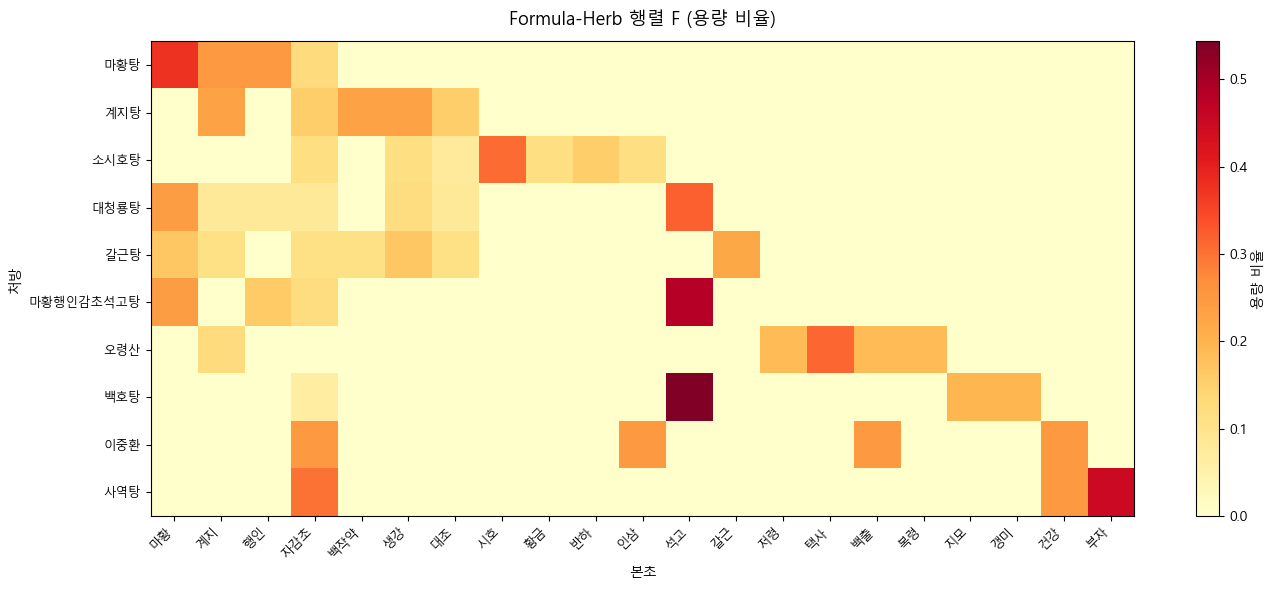

저장: data/F_heatmap.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(F_display.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='용량 비율')

ax.set_xticks(range(len(F_display.columns)))
ax.set_xticklabels(F_display.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(F_display.index)))
ax.set_yticklabels(F_display.index, fontsize=9)

ax.set_title('Formula-Herb 행렬 F (용량 비율)', fontsize=13, pad=12)
ax.set_xlabel('본초')
ax.set_ylabel('처방')

plt.tight_layout()
plt.savefig('../data/F_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: data/F_heatmap.png')

## 3. S 행렬 — 처방-증상 히트맵

In [11]:
S = build_formula_symptom_matrix(formulas_df, syndromes_df)
print('S 행렬 shape:', S.shape)

# symptom_id → 이름 변환
symp_df = expand_symptoms(syndromes_df)
sid_to_name = symp_df.drop_duplicates('symptom_id').set_index('symptom_id')['name_kr'].to_dict()

S_display = S.rename(index=formula_names, columns=sid_to_name)
S_display.round(2)

S 행렬 shape: (10, 47)


symptom_id,오한,발열,무한,두통,신체통,천기,맥부긴,요통,골절통,오풍,...,설사,식욕부진,사지불온,맥침지,사지궐냉,오한권와,맥미욕절,하리청곡,신피,면색창백
formula_id,,,,,,,,,,,,,,,,,,,,,
마황탕,1.5,1.0,1.5,1.00,1.20,0.40,0.5,0.30,0.35,0.00,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00
계지탕,0.0,1.0,0.0,1.00,0.00,0.00,0.0,0.00,0.00,1.50,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00
소시호탕,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00
대청룡탕,1.0,1.2,1.0,0.30,1.00,0.24,0.4,0.18,0.21,0.00,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00
갈근탕,1.0,1.0,1.0,1.00,0.36,0.24,0.3,0.18,0.21,0.45,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00
마황행인감초석고탕,0.0,1.2,0.0,0.00,0.00,1.50,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00
오령산,0.0,0.3,0.0,0.25,0.00,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00
백호탕,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00
이중환,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,1.2,1.0,0.4,0.5,0.54,0.39,0.45,0.3,0.24,0.21


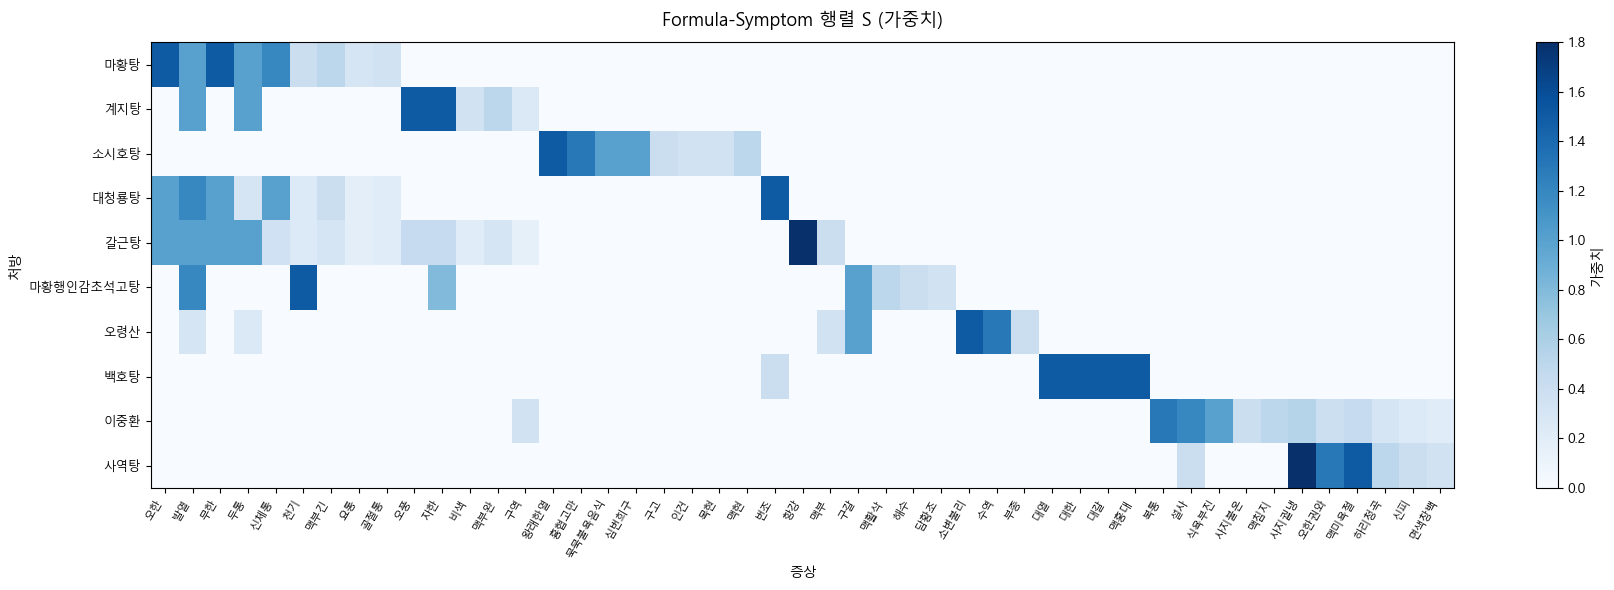

저장: data/S_heatmap.png


In [12]:
fig, ax = plt.subplots(figsize=(18, 6))

im = ax.imshow(S_display.values, aspect='auto', cmap='Blues')
plt.colorbar(im, ax=ax, label='가중치')

ax.set_xticks(range(len(S_display.columns)))
ax.set_xticklabels(S_display.columns, rotation=60, ha='right', fontsize=8)
ax.set_yticks(range(len(S_display.index)))
ax.set_yticklabels(S_display.index, fontsize=9)

ax.set_title('Formula-Symptom 행렬 S (가중치)', fontsize=13, pad=12)
ax.set_xlabel('증상')
ax.set_ylabel('처방')

plt.tight_layout()
plt.savefig('../data/S_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: data/S_heatmap.png')

## 4. 처방 간 코사인 유사도

In [13]:
sim_F = cosine_similarity_matrix(F)
sim_F_display = sim_F.rename(index=formula_names, columns=formula_names)

print('=== 처방 간 유사도 (본초 구성 기반) ===')
sim_F_display.round(3)

=== 처방 간 유사도 (본초 구성 기반) ===


formula_id,마황탕,계지탕,소시호탕,대청룡탕,갈근탕,마황행인감초석고탕,오령산,백호탕,이중환,사역탕
formula_id,,,,,,,,,,
마황탕,1.000,0.319,0.065,0.590,0.500,0.477,0.126,0.025,0.118,0.119
계지탕,0.319,1.000,0.293,0.348,0.693,0.071,0.136,0.036,0.169,0.170
소시호탕,0.065,0.293,1.000,0.155,0.245,0.057,0.000,0.029,0.274,0.138
대청룡탕,0.590,0.348,0.155,1.000,0.493,0.912,0.048,0.653,0.089,0.090
갈근탕,0.500,0.693,0.245,0.493,1.000,0.237,0.076,0.030,0.141,0.142
마황행인감초석고탕,0.477,0.071,0.057,0.912,0.237,1.000,0.000,0.765,0.105,0.105
오령산,0.126,0.136,0.000,0.048,0.076,0.000,1.000,0.000,0.200,0.000
백호탕,0.025,0.036,0.029,0.653,0.030,0.765,0.000,1.000,0.053,0.054
이중환,0.118,0.169,0.274,0.089,0.141,0.105,0.200,0.053,1.000,0.462


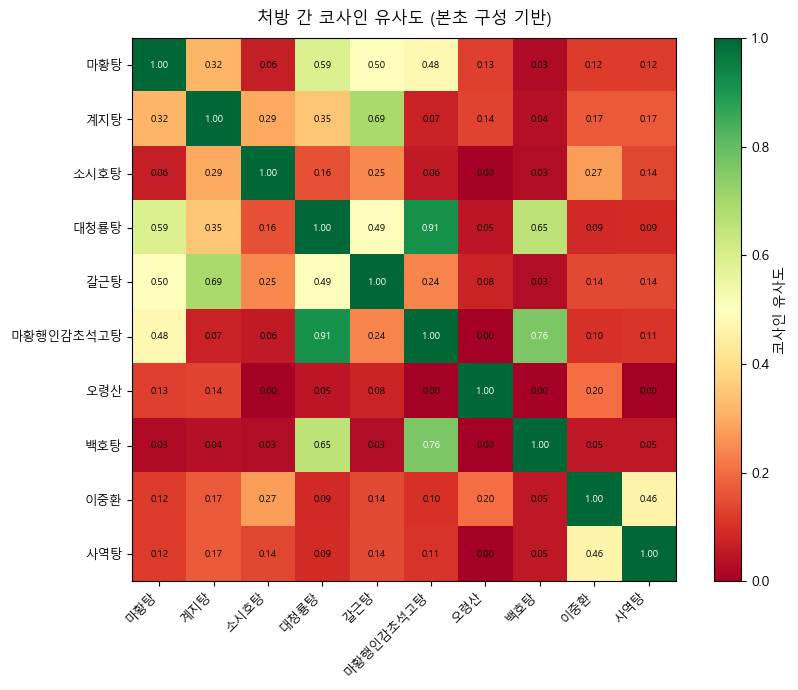

In [14]:
def plot_similarity_heatmap(sim_df, title):
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(sim_df.values, vmin=0, vmax=1, cmap='RdYlGn')
    plt.colorbar(im, ax=ax, label='코사인 유사도')

    labels = list(sim_df.index)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)

    # 셀 값 표시
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = sim_df.values[i, j]
            color = 'white' if val > 0.7 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color=color)

    ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

plot_similarity_heatmap(sim_F_display, '처방 간 코사인 유사도 (본초 구성 기반)')

=== 처방 간 유사도 (증상 기반) ===


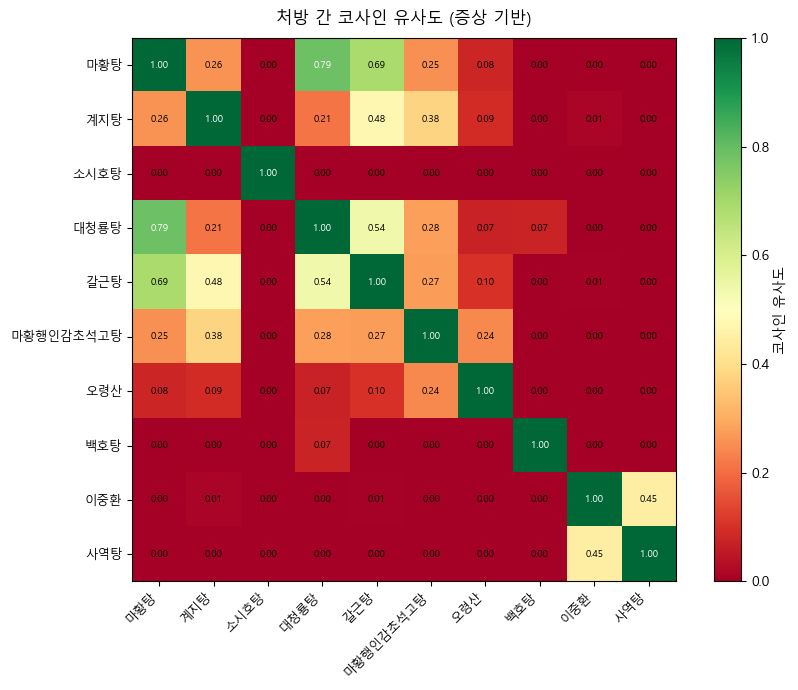

formula_id,마황탕,계지탕,소시호탕,대청룡탕,갈근탕,마황행인감초석고탕,오령산,백호탕,이중환,사역탕
formula_id,,,,,,,,,,
마황탕,1.000,0.260,0.0,0.787,0.688,0.254,0.081,0.000,0.000,0.000
계지탕,0.260,1.000,0.0,0.214,0.476,0.376,0.090,0.000,0.014,0.000
소시호탕,0.000,0.000,1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
대청룡탕,0.787,0.214,0.0,1.000,0.536,0.280,0.071,0.075,0.000,0.000
갈근탕,0.688,0.476,0.0,0.536,1.000,0.275,0.103,0.000,0.008,0.000
마황행인감초석고탕,0.254,0.376,0.0,0.280,0.275,1.000,0.242,0.000,0.000,0.000
오령산,0.081,0.090,0.0,0.071,0.103,0.242,1.000,0.000,0.000,0.000
백호탕,0.000,0.000,0.0,0.075,0.000,0.000,0.000,1.000,0.000,0.000
이중환,0.000,0.014,0.0,0.000,0.008,0.000,0.000,0.000,1.000,0.449


In [15]:
sim_S = cosine_similarity_matrix(S)
sim_S_display = sim_S.rename(index=formula_names, columns=formula_names)

print('=== 처방 간 유사도 (증상 기반) ===')
plot_similarity_heatmap(sim_S_display, '처방 간 코사인 유사도 (증상 기반)')
sim_S_display.round(3)

## 5. 증상 쿼리 → 처방 추천 테스트

환자 증상을 리스트로 입력하면 가장 유사한 처방을 추천합니다.

In [16]:
name_idx = build_symptom_name_index(syndromes_df)
print('인식 가능한 증상 목록:')
print(list(name_idx.keys()))

인식 가능한 증상 목록:
['오한', '발열', '무한', '두통', '신체통', '천기', '맥부긴', '요통', '골절통', '오풍', '자한', '비색', '맥부완', '구역', '왕래한열', '흉협고만', '묵묵불욕음식', '심번희구', '구고', '인건', '목현', '맥현', '번조', '항강', '맥부', '구갈', '맥활삭', '해수', '담황조', '소변불리', '수역', '부종', '대열', '대한', '대갈', '맥홍대', '복통', '설사', '식욕부진', '사지불온', '맥침지', '사지궐냉', '오한권와', '맥미욕절', '하리청곡', '신피', '면색창백']


In [17]:
def recommend(symptoms: list, top_k: int = 5):
    """
    증상 이름 리스트를 받아 상위 top_k 처방을 반환.
    참고용 출력이며 임상 판단을 대체하지 않습니다.
    """
    missing = [s for s in symptoms if s not in name_idx]
    if missing:
        print(f'[경고] 데이터에 없는 증상: {missing}')

    q = pd.Series({name_idx[s]: 1.0 for s in symptoms if s in name_idx})
    if q.empty:
        print('유효한 증상이 없습니다.')
        return

    scores = query_similarity(q, S)
    print(f'\n[쿼리] {symptoms}')
    print(f'{'처방':<20} {'유사도':>8}  변증')
    print('-' * 50)
    for fid, score in scores.head(top_k).items():
        fname = formulas_df.loc[fid, 'name_kr']
        syn_ids = formulas_df.loc[fid, 'indications']['syndromes']
        syn_names = ', '.join(syndromes_df.loc[s, 'name_kr'] for s in syn_ids if s in syndromes_df.index)
        print(f'{fname:<20} {score:>8.4f}  {syn_names}')
    print('\n⚠️ 참고용 — 최종 처방은 임상의가 판단해야 합니다.')


# 테스트 1: 태양병 상한증 전형 증상
recommend(['오한', '발열', '무한', '두통', '신체통'])


[쿼리] ['오한', '발열', '무한', '두통', '신체통']
처방                        유사도  변증
--------------------------------------------------
마황탕                    0.9840  태양병 상한증
갈근탕                    0.9595  태양병 경항강급증
대청룡탕                   0.9455  태양병 표한리열증
계지탕                    0.6325  태양병 중풍증
오령산                    0.6299  수습내정 겸 표증

⚠️ 참고용 — 최종 처방은 임상의가 판단해야 합니다.


In [18]:
# 테스트 2: 태양병 중풍증 전형 증상
recommend(['발열', '오풍', '자한', '두통'])


[쿼리] ['발열', '오풍', '자한', '두통']
처방                        유사도  변증
--------------------------------------------------
계지탕                    0.9806  태양병 중풍증
갈근탕                    0.9350  태양병 경항강급증
마황탕                    0.7071  태양병 상한증
오령산                    0.7042  수습내정 겸 표증
마황행인감초석고탕              0.6934  폐열옹성증

⚠️ 참고용 — 최종 처방은 임상의가 판단해야 합니다.


In [19]:
# 테스트 3: 소양병 증상
recommend(['왕래한열', '흉협고만', '구고', '인건'])


[쿼리] ['왕래한열', '흉협고만', '구고', '인건']
처방                        유사도  변증
--------------------------------------------------
소시호탕                   0.8638  소양병증
마황탕                    0.0000  태양병 상한증
계지탕                    0.0000  태양병 중풍증
대청룡탕                   0.0000  태양병 표한리열증
갈근탕                    0.0000  태양병 경항강급증

⚠️ 참고용 — 최종 처방은 임상의가 판단해야 합니다.


In [20]:
# 테스트 4: 양명경증 4대증
recommend(['대열', '대한', '대갈', '맥홍대'])


[쿼리] ['대열', '대한', '대갈', '맥홍대']
처방                        유사도  변증
--------------------------------------------------
백호탕                    1.0000  양명경증
마황탕                    0.0000  태양병 상한증
계지탕                    0.0000  태양병 중풍증
소시호탕                   0.0000  소양병증
갈근탕                    0.0000  태양병 경항강급증

⚠️ 참고용 — 최종 처방은 임상의가 판단해야 합니다.


In [21]:
# 테스트 5: 소음병 한증
recommend(['사지궐냉', '오한권와', '맥미욕절'])


[쿼리] ['사지궐냉', '오한권와', '맥미욕절']
처방                        유사도  변증
--------------------------------------------------
사역탕                    0.9911  소음병 한화쇠미증
이중환                    0.9911  비위허한증
계지탕                    0.0000  태양병 중풍증
마황탕                    0.0000  태양병 상한증
소시호탕                   0.0000  소양병증

⚠️ 참고용 — 최종 처방은 임상의가 판단해야 합니다.


## 6. 처방 비교 — 마황탕 vs 계지탕

In [22]:
def compare_formulas(fid_a: str, fid_b: str):
    """두 처방의 본초 구성과 코사인 유사도를 비교. 참고용."""
    fa = formulas_df.loc[fid_a]
    fb = formulas_df.loc[fid_b]

    herbs_a = {item['herb_id']: item for item in fa['composition']}
    herbs_b = {item['herb_id']: item for item in fb['composition']}

    common = set(herbs_a) & set(herbs_b)
    only_a = set(herbs_a) - set(herbs_b)
    only_b = set(herbs_b) - set(herbs_a)

    sim = float(sim_F.loc[fid_a, fid_b])

    print(f'=== {fa["name_kr"]} vs {fb["name_kr"]} ===')
    print(f'코사인 유사도 (본초 기반): {sim:.4f}')
    print()

    print(f'공통 본초 ({len(common)}종):')
    for hid in sorted(common):
        ha, hb = herbs_a[hid], herbs_b[hid]
        print(f'  {ha["name_kr"]:8s}  {fa["name_kr"]}: {ha["dose_g"]}g  |  {fb["name_kr"]}: {hb["dose_g"]}g')

    print(f'\n{fa["name_kr"]} 고유 ({len(only_a)}종):')
    for hid in sorted(only_a):
        h = herbs_a[hid]
        print(f'  {h["name_kr"]:8s}  {h["dose_g"]}g  [{h["role"]}]')

    print(f'\n{fb["name_kr"]} 고유 ({len(only_b)}종):')
    for hid in sorted(only_b):
        h = herbs_b[hid]
        print(f'  {h["name_kr"]:8s}  {h["dose_g"]}g  [{h["role"]}]')

    print('\n⚠️ 참고용 — 임상 적용은 전문가 판단이 필요합니다.')


compare_formulas('SHL_001', 'SHL_002')

=== 마황탕 vs 계지탕 ===
코사인 유사도 (본초 기반): 0.3187

공통 본초 (2종):
  계지        마황탕: 6g  |  계지탕: 9g
  자감초       마황탕: 3g  |  계지탕: 6g

마황탕 고유 (2종):
  마황        9g  [군]
  행인        6g  [좌]

계지탕 고유 (3종):
  백작약       9g  [신]
  생강        9g  [좌]
  대조        6g  [사]

⚠️ 참고용 — 임상 적용은 전문가 판단이 필요합니다.


In [23]:
# 마황탕 vs 대청룡탕 (마황탕 + 석고)
compare_formulas('SHL_001', 'SHL_004')

=== 마황탕 vs 대청룡탕 ===
코사인 유사도 (본초 기반): 0.5903

공통 본초 (4종):
  마황        마황탕: 9g  |  대청룡탕: 18g
  계지        마황탕: 6g  |  대청룡탕: 6g
  행인        마황탕: 6g  |  대청룡탕: 6g
  자감초       마황탕: 3g  |  대청룡탕: 6g

마황탕 고유 (0종):

대청룡탕 고유 (3종):
  생강        9g  [좌]
  대조        6g  [좌]
  석고        24g  [신]

⚠️ 참고용 — 임상 적용은 전문가 판단이 필요합니다.


---
## Phase 0 완료 체크리스트

- [x] `load_data.py` — JSON → DataFrame 로드 확인
- [x] `build_matrices.py` — F, S 행렬 생성 확인
- [x] F 행렬 히트맵 시각화
- [x] S 행렬 히트맵 시각화
- [x] 처방 간 유사도 확인 (본초 기반, 증상 기반)
- [x] 증상 쿼리 → 처방 추천 테스트
- [ ] **연구자 검증**: 시드 데이터 용량, 군신좌사 배정, 증상 가중치 검토 후 수정

다음 단계 → `src/engine.py` (Phase 1)